# Post 02: What Does an MD Integrator Actually Approximate?

This notebook is the presentation layer for the second tutorial. The reusable harmonic oscillator integrator diagnostics and figure logic live in `src/kups_md_tutorials/`.

The goal is to separate three ideas that are often conflated: the differential equation, the discrete update rule, and the diagnostics that reveal whether the update rule is behaving like a useful molecular-dynamics integrator.

In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.config import load_integrator_spec
from kups_md_tutorials.figures import generate_post02_figures
from kups_md_tutorials.integrators import (
    exact_harmonic,
    integrate_harmonic,
    load_integrator_summary,
)

## Configuration

The smoke and full profiles use the same harmonic oscillator and the same pair of update rules. The full profile sweeps more timesteps and runs longer, so it is the source for the diagnostic figure.

In [3]:
smoke_spec = load_integrator_spec("02", "smoke")
full_spec = load_integrator_spec("02", "full")

for label in ["smoke", "full"]:
    config_path = Path(f"configs/post-02/{label}.json")
    print(f"--- {label} ---")
    print(json.dumps(json.loads(config_path.read_text()), indent=2))

--- smoke ---
{
  "post": "02",
  "profile": "smoke",
  "title": "What Does an MD Integrator Actually Approximate?",
  "system": {
    "kind": "harmonic_oscillator",
    "mass": 1.0,
    "omega": 1.0,
    "position": 1.0,
    "velocity": 0.0
  },
  "integrator_experiment": {
    "seed": 2026071402,
    "time_steps": [
      0.04,
      0.12
    ],
    "num_steps": 400,
    "integrators": [
      "velocity_verlet",
      "explicit_euler"
    ],
    "reference_integrator": "velocity_verlet"
  }
}
--- full ---
{
  "post": "02",
  "profile": "full",
  "title": "What Does an MD Integrator Actually Approximate?",
  "system": {
    "kind": "harmonic_oscillator",
    "mass": 1.0,
    "omega": 1.0,
    "position": 1.0,
    "velocity": 0.0
  },
  "integrator_experiment": {
    "seed": 2026071402,
    "time_steps": [
      0.02,
      0.05,
      0.1,
      0.2
    ],
    "num_steps": 2000,
    "integrators": [
      "velocity_verlet",
      "explicit_euler"
    ],
    "reference_integrator": "ve

## A Discrete Map, Not The Equation Itself

For the oscillator \(\ddot q=-\omega^2 q\), the exact trajectory is known. That gives a useful microscope for integrator behavior: we can compare the numerical map against the exact orbit, the energy, and a forward/backward reversibility check.

In [4]:
times, verlet_q, verlet_v = integrate_harmonic(
    "velocity_verlet",
    time_step=0.2,
    num_steps=12,
    mass=full_spec.system.mass,
    omega=full_spec.system.omega,
    position0=full_spec.system.position,
    velocity0=full_spec.system.velocity,
)
exact_q, exact_v = exact_harmonic(
    times,
    full_spec.system.position,
    full_spec.system.velocity,
    full_spec.system.omega,
)
list(zip(times[:5], verlet_q[:5], exact_q[:5], verlet_v[:5], exact_v[:5]))

[(np.float64(0.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.0),
  np.float64(0.0)),
 (np.float64(0.2),
  np.float64(0.98),
  np.float64(0.9800665778412416),
  np.float64(-0.198),
  np.float64(-0.19866933079506122)),
 (np.float64(0.4),
  np.float64(0.9208000000000001),
  np.float64(0.9210609940028851),
  np.float64(-0.38808000000000004),
  np.float64(-0.3894183423086505)),
 (np.float64(0.6000000000000001),
  np.float64(0.8247680000000001),
  np.float64(0.8253356149096782),
  np.float64(-0.5626368),
  np.float64(-0.5646424733950355)),
 (np.float64(0.8),
  np.float64(0.6957452800000001),
  np.float64(0.6967067093471654),
  np.float64(-0.7146881280000001),
  np.float64(-0.7173560908995228))]

## Committed Outputs

The repository commits compact smoke and full summaries plus a downsampled trajectory table for the reference velocity-Verlet run. The summaries are the source of the post-level diagnostics.

In [5]:
result_dirs = {
    "smoke": Path("results/post-02/smoke"),
    "full": Path("results/post-02/full"),
}

for label, result_dir in result_dirs.items():
    print(f"--- {label} ---")
    for path in sorted(result_dir.iterdir()):
        print(f"{path}: {path.stat().st_size} bytes")

full_summary = load_integrator_summary(result_dirs["full"] / "integrator_summary.json")
full_summary

--- smoke ---
results/post-02/smoke/integrator_summary.json: 2082 bytes
results/post-02/smoke/manifest.json: 1247 bytes
results/post-02/smoke/trajectory_samples.csv: 33388 bytes
--- full ---
results/post-02/full/integrator_summary.json: 3942 bytes
results/post-02/full/manifest.json: 1272 bytes
results/post-02/full/trajectory_samples.csv: 41618 bytes


IntegratorExperimentSummary(post='02', profile='full', seed=2026071402, mass=1.0, omega=1.0, initial_position=1.0, initial_velocity=0.0, config_sha256='f50d0058bc90342e80be4a9ea6e7b25bbd7defbfe39a5bec72e27056ea46e388', runs=[IntegratorRunSummary(integrator='velocity_verlet', time_step=0.02, num_steps=2000, final_time=40.0, initial_energy=0.5, final_energy=0.49997227345245915, signed_energy_drift=-2.7726547540851687e-05, max_abs_relative_energy_error=9.999999998844267e-05, rms_position_error=0.0002772572656159837, final_position_error=-0.0004966162031179167, reversibility_error=3.583003205628631e-15), IntegratorRunSummary(integrator='explicit_euler', time_step=0.02, num_steps=2000, final_time=40.0, initial_energy=0.5, final_energy=1.1125924826710307, signed_energy_drift=0.6125924826710307, max_abs_relative_energy_error=1.2251849653420614, rms_position_error=0.18680968330772932, final_position_error=-0.32199640339492297, reversibility_error=1.225184965342062), IntegratorRunSummary(integr

## Diagnostic Figure

The figure uses the full profile. It checks that velocity Verlet tracks the exact phase-space orbit, that its energy error stays bounded on this sweep, and that the forward/backward map returns to the initial state up to roundoff.

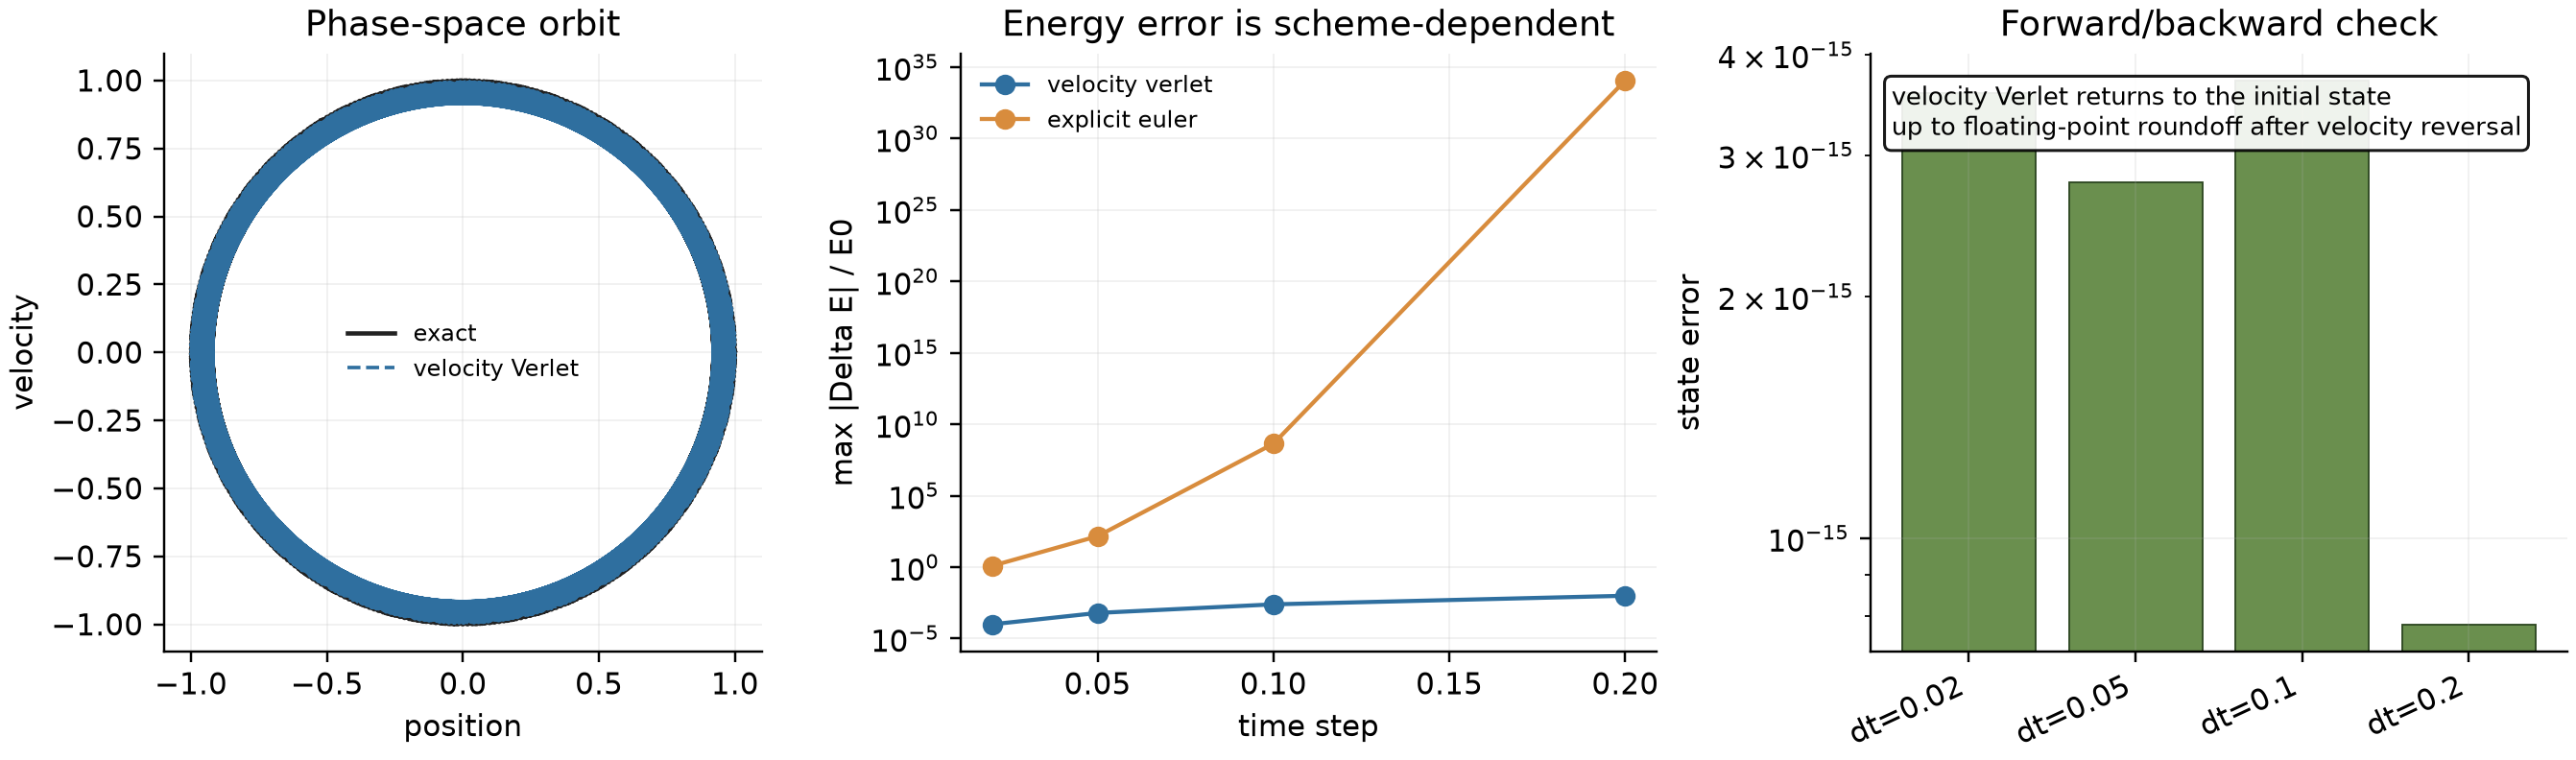

In [6]:
generate_post02_figures(
    result_dir=result_dirs["full"],
    figure_dir=Path("figures/post-02"),
    snapshot_dir=Path("snapshots/post-02"),
    name="integrator_diagnostics_full",
)
display(Image(filename="figures/post-02/integrator_diagnostics_full.png"))

## Takeaways

- The integrator is a discrete map that approximates the flow, not the equation of motion itself.
- Velocity Verlet is time-reversible for this separable Hamiltonian test up to floating-point roundoff.
- Bounded energy error and systematic energy drift are different diagnostics.
- A failure contrast such as explicit Euler makes the structure of the useful integrator easier to see.